In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load cleaned data
df = pd.read_csv('../data/cleaned/taxi_cleaned.csv')
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Global chart style settings
plt.rcParams['figure.facecolor'] = '#f9f9f9'
plt.rcParams['axes.facecolor']   = '#ffffff'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize']   = 11

print(f"✅ Data loaded: {len(df):,} rows")
print("✅ Chart style configured")

✅ Data loaded: 601,662 rows
✅ Chart style configured


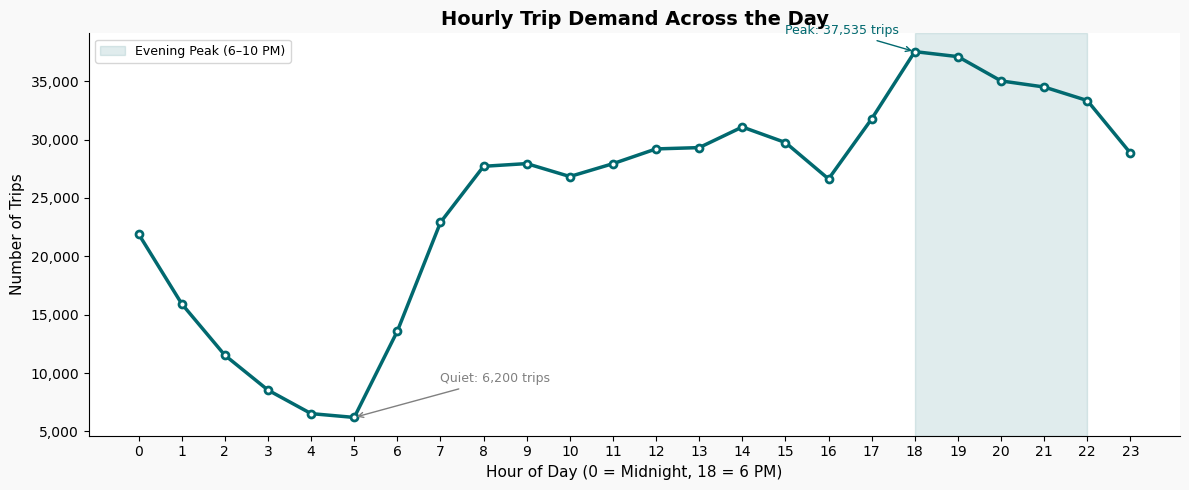

✅ Chart 1 saved to screenshots/


In [2]:
hourly = df.groupby('hour_of_day').size().reset_index(name='trip_count')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hourly['hour_of_day'], hourly['trip_count'],
        color='#01696f', linewidth=2.5, marker='o',
        markersize=5, markerfacecolor='white', markeredgewidth=2)

# Shade the evening peak zone
ax.axvspan(18, 22, alpha=0.12, color='#01696f', label='Evening Peak (6–10 PM)')

# Mark peak and quiet
peak_row  = hourly.loc[hourly['trip_count'].idxmax()]
quiet_row = hourly.loc[hourly['trip_count'].idxmin()]

ax.annotate(f"Peak: {int(peak_row['trip_count']):,} trips",
            xy=(peak_row['hour_of_day'], peak_row['trip_count']),
            xytext=(15, peak_row['trip_count'] + 1500),
            fontsize=9, color='#01696f',
            arrowprops=dict(arrowstyle='->', color='#01696f'))

ax.annotate(f"Quiet: {int(quiet_row['trip_count']):,} trips",
            xy=(quiet_row['hour_of_day'], quiet_row['trip_count']),
            xytext=(7, quiet_row['trip_count'] + 3000),
            fontsize=9, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_title('Hourly Trip Demand Across the Day')
ax.set_xlabel('Hour of Day (0 = Midnight, 18 = 6 PM)')
ax.set_ylabel('Number of Trips')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../screenshots/chart1_hourly_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved to screenshots/")

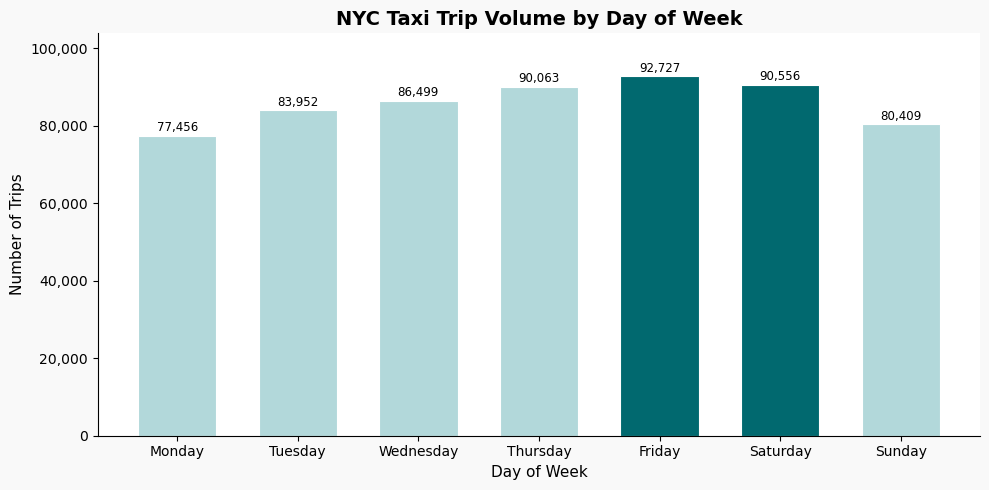

✅ Chart 2 saved to screenshots/


In [3]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_of_week').size().reset_index(name='trip_count')
daily['day_of_week'] = pd.Categorical(daily['day_of_week'], categories=day_order, ordered=True)
daily = daily.sort_values('day_of_week')

# Color Friday and Saturday darker to highlight busiest days
colors = ['#b2d8da' if d not in ['Friday','Saturday'] else '#01696f'
          for d in daily['day_of_week']]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(daily['day_of_week'], daily['trip_count'],
              color=colors, edgecolor='white', linewidth=0.8, width=0.65)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 400,
            f'{int(height):,}', ha='center', va='bottom', fontsize=8.5)

ax.set_title('NYC Taxi Trip Volume by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, daily['trip_count'].max() * 1.12)

plt.tight_layout()
plt.savefig('../screenshots/chart2_daily_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved to screenshots/")

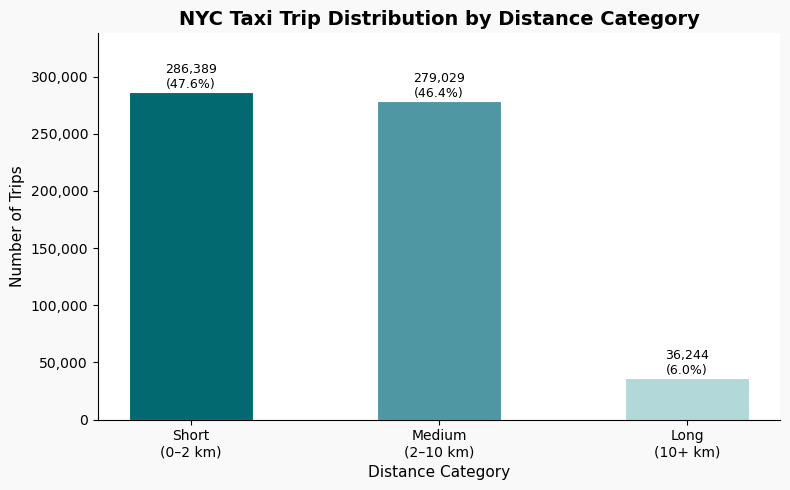

✅ Chart 3 saved to screenshots/


In [4]:
bucket_order = ['Short\n(0–2 km)', 'Medium\n(2–10 km)', 'Long\n(10+ km)']
bucket_counts = [
    df[df['distance_bucket'] == 'Short'].shape[0],
    df[df['distance_bucket'] == 'Medium'].shape[0],
    df[df['distance_bucket'] == 'Long'].shape[0]
]
bucket_pcts = [c / len(df) * 100 for c in bucket_counts]

colors_bucket = ['#01696f', '#4f98a3', '#b2d8da']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(bucket_order, bucket_counts,
              color=colors_bucket, edgecolor='white', linewidth=0.8, width=0.5)

for bar, pct in zip(bars, bucket_pcts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1000,
            f'{int(height):,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_title('NYC Taxi Trip Distribution by Distance Category')
ax.set_xlabel('Distance Category')
ax.set_ylabel('Number of Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, max(bucket_counts) * 1.18)

plt.tight_layout()
plt.savefig('../screenshots/chart3_distance_buckets.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved to screenshots/")

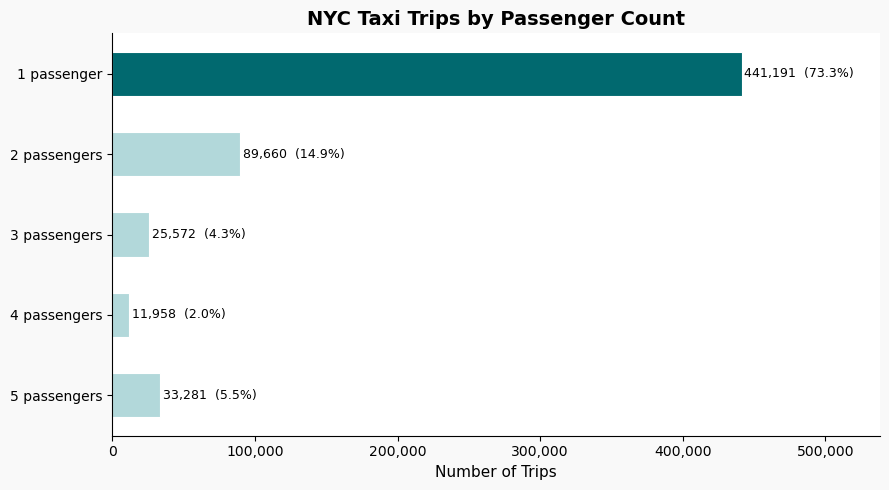

✅ Chart 4 saved to screenshots/


In [5]:
pax = df.groupby('passenger_count').size().reset_index(name='trip_count')
pax['pct'] = (pax['trip_count'] / pax['trip_count'].sum() * 100).round(1)
pax['label'] = pax['passenger_count'].astype(str) + ' passenger' + \
               pax['passenger_count'].apply(lambda x: 's' if x > 1 else '')

colors_pax = ['#01696f' if p == 1 else '#b2d8da' for p in pax['passenger_count']]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(pax['label'], pax['trip_count'],
               color=colors_pax, edgecolor='white', linewidth=0.8, height=0.55)

for bar, pct in zip(bars, pax['pct']):
    width = bar.get_width()
    ax.text(width + 2000, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}  ({pct}%)', va='center', fontsize=9)

ax.set_title('NYC Taxi Trips by Passenger Count')
ax.set_xlabel('Number of Trips')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, pax['trip_count'].max() * 1.22)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../screenshots/chart4_passenger_count.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved to screenshots/")

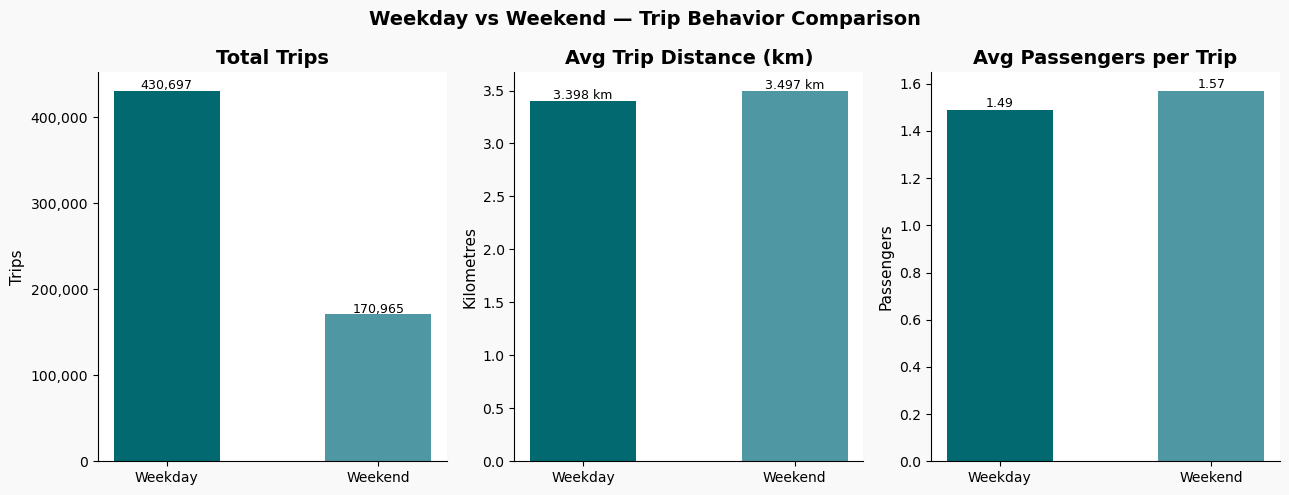

✅ Chart 5 saved to screenshots/


In [6]:
weekend_data = df.groupby('is_weekend').agg(
    total_trips     = ('id', 'count'),
    avg_distance_km = ('trip_distance_km', 'mean'),
    avg_passengers  = ('passenger_count', 'mean')
).reset_index()

labels   = ['Weekday', 'Weekend']
trips    = weekend_data['total_trips'].tolist()
avg_dist = weekend_data['avg_distance_km'].round(3).tolist()
avg_pax  = weekend_data['avg_passengers'].round(2).tolist()

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Weekday vs Weekend — Trip Behavior Comparison', fontsize=14, fontweight='bold')

colors_wk = ['#01696f', '#4f98a3']

# Panel 1 — Total trips
axes[0].bar(labels, trips, color=colors_wk, width=0.5)
axes[0].set_title('Total Trips')
axes[0].set_ylabel('Trips')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(trips):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=9)

# Panel 2 — Avg distance
axes[1].bar(labels, avg_dist, color=colors_wk, width=0.5)
axes[1].set_title('Avg Trip Distance (km)')
axes[1].set_ylabel('Kilometres')
for i, v in enumerate(avg_dist):
    axes[1].text(i, v + 0.02, f'{v:.3f} km', ha='center', fontsize=9)

# Panel 3 — Avg passengers
axes[2].bar(labels, avg_pax, color=colors_wk, width=0.5)
axes[2].set_title('Avg Passengers per Trip')
axes[2].set_ylabel('Passengers')
for i, v in enumerate(avg_pax):
    axes[2].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../screenshots/chart5_weekday_weekend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved to screenshots/")

## Dashboard Chart Decisions

**Selected for web dashboard (3 strongest):**
- **Chart 1** - Hourly Trip Demand: Shows the 24-hour traffic story
- **Chart 2** - Trips by Day of Week: Shows weekly pattern clearly
- **Chart 3** - Distance Bucket Distribution: Simple 3-category split

**Reference only (README / documentation):**
- Chart 4 - Passenger Count: Strong visual but not essential for dashboard
- Chart 5 - Weekday vs Weekend: Good context, could become a toggle filter